In [8]:
import json

def _collect_epoch_wise_episode_len(file):
    epoch_average_return = {}
    with open(file, "r") as f:
        data = f.readlines()
    for line in data:
        epoch_number = int(line.split("epoch:")[1].split("loss")[0].strip())
        epoch_length = float(line.split("ep_len:")[1].strip())
        epoch_average_return[epoch_number] = epoch_length

    return epoch_average_return

In [12]:
import glob

ground_truth_epoch_return_files = glob.glob("log_[01234]/log.txt")
ground_truth_epoch_average_return_dict = {}
for file in ground_truth_epoch_return_files:
    num = int(file.split("log_")[1].split("/log")[0].strip())
    ground_truth_epoch_average_return_dict[num] = _collect_epoch_wise_episode_len(file)

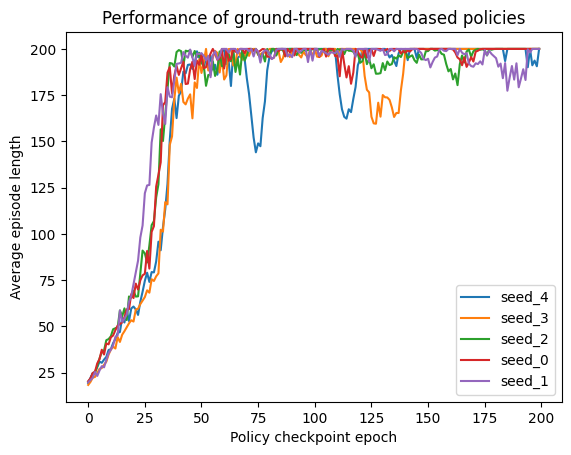

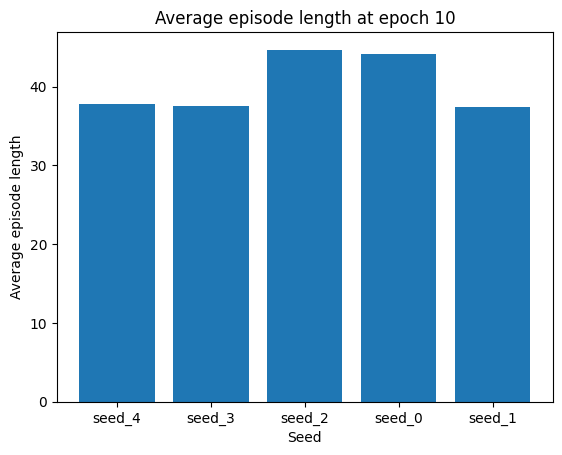

Mean average episode length at epoch 10: 40.29


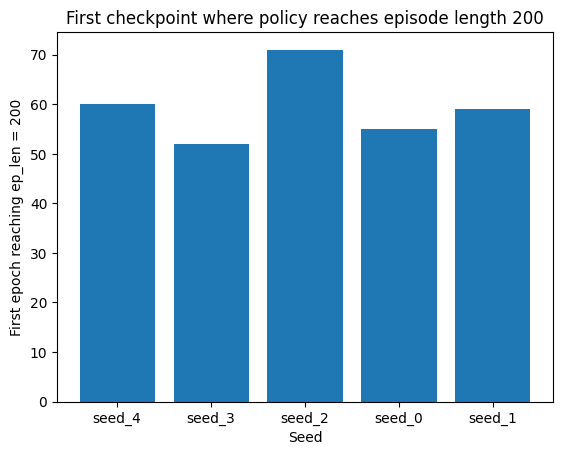


First epoch where average episode length reaches 200:
seed_4: 60
seed_3: 52
seed_2: 71
seed_0: 55
seed_1: 59


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------
# Plot 1: original performance plot
# ----------------------------------------
plt.figure()

for run_id, epoch_dict in ground_truth_epoch_average_return_dict.items():
    epochs = sorted(epoch_dict.keys())
    values = [epoch_dict[e] for e in epochs]
    plt.plot(epochs, values, label=f"seed_{run_id}")

plt.xlabel("Policy checkpoint epoch")
plt.ylabel("Average episode length")
plt.title("Performance of ground-truth reward based policies")
plt.legend()
plt.show()


# ----------------------------------------
# Plot 2: episode length at epoch 10
# ----------------------------------------
checkpoint_epoch = 10
seed_ids = []
vals_at_10 = []

for run_id, epoch_dict in ground_truth_epoch_average_return_dict.items():
    if checkpoint_epoch in epoch_dict:
        seed_ids.append(f"seed_{run_id}")
        vals_at_10.append(epoch_dict[checkpoint_epoch])

plt.figure()
plt.bar(seed_ids, vals_at_10)
plt.xlabel("Seed")
plt.ylabel("Average episode length")
plt.title(f"Average episode length at epoch {checkpoint_epoch}")
plt.show()

if vals_at_10:
    print(f"Mean average episode length at epoch {checkpoint_epoch}: {np.mean(vals_at_10):.2f}")


# ----------------------------------------
# Plot 3: first epoch where ep_len reaches 200
# ----------------------------------------
threshold = 200
seed_ids = []
first_hit_epochs = []

for run_id, epoch_dict in ground_truth_epoch_average_return_dict.items():
    epochs = sorted(epoch_dict.keys())
    hit_epoch = None
    for e in epochs:
        if epoch_dict[e] >= threshold:
            hit_epoch = e
            break

    if hit_epoch is not None:
        seed_ids.append(f"seed_{run_id}")
        first_hit_epochs.append(hit_epoch)

plt.figure()
plt.bar(seed_ids, first_hit_epochs)
plt.xlabel("Seed")
plt.ylabel("First epoch reaching ep_len = 200")
plt.title("First checkpoint where policy reaches episode length 200")
plt.show()

print("\nFirst epoch where average episode length reaches 200:")
for run_id, epoch_dict in ground_truth_epoch_average_return_dict.items():
    epochs = sorted(epoch_dict.keys())
    hit_epoch = None
    for e in epochs:
        if epoch_dict[e] >= threshold:
            hit_epoch = e
            break
    print(f"seed_{run_id}: {hit_epoch}")

In [22]:
checkpoint_epoch = 10

rows = []
vals_at_10 = []

for run_id, epoch_dict in ground_truth_epoch_average_return_dict.items():
    val = epoch_dict.get(checkpoint_epoch, None)
    rows.append((run_id, val))
    if val is not None:
        vals_at_10.append(val)

# print markdown table
print(f"### Episode Length at Epoch {checkpoint_epoch}\n")
print("| Seed | Episode Length |")
print("|------|----------------|")

for run_id, val in rows:
    val_str = f"{val:.2f}" if val is not None else "N/A"
    print(f"| seed_{run_id} | {val_str} |")

if vals_at_10:
    mean_val = sum(vals_at_10) / len(vals_at_10)
    print(f"\n**Mean across seeds:** {mean_val:.2f}")

### Episode Length at Epoch 10

| Seed | Episode Length |
|------|----------------|
| seed_4 | 37.73 |
| seed_3 | 37.48 |
| seed_2 | 44.69 |
| seed_0 | 44.15 |
| seed_1 | 37.40 |

**Mean across seeds:** 40.29


In [23]:
threshold = 200

rows = []

for run_id, epoch_dict in ground_truth_epoch_average_return_dict.items():
    epochs = sorted(epoch_dict.keys())
    hit_epoch = None
    hit_value = None

    for e in epochs:
        if epoch_dict[e] >= threshold:
            hit_epoch = e
            hit_value = epoch_dict[e]
            break

    rows.append((run_id, hit_epoch, hit_value))

# print markdown table
print(f"\n### First Epoch Reaching Episode Length ≥ {threshold}\n")
print("| Seed | First Epoch | Episode Length |")
print("|------|-------------|----------------|")

for run_id, ep, val in rows:
    ep_str = str(ep) if ep is not None else "N/A"
    val_str = f"{val:.2f}" if val is not None else "N/A"
    print(f"| seed_{run_id} | {ep_str} | {val_str} |")


### First Epoch Reaching Episode Length ≥ 200

| Seed | First Epoch | Episode Length |
|------|-------------|----------------|
| seed_4 | 60 | 200.00 |
| seed_3 | 52 | 200.00 |
| seed_2 | 71 | 200.00 |
| seed_0 | 55 | 200.00 |
| seed_1 | 59 | 200.00 |


In [48]:
import torch
import numpy as np
from utils import Net

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
reward_net = Net()
reward_net.load_state_dict(torch.load("reward.params"))
reward_net.to(device)

def sample_states(n=1000):
    ## reasonable bounds for velocities, including terminating positions for comparability.
    low = np.array([-2.4, -5.0, -0.208, -5.0])
    high = np.array([2.4, 5.0, 0.208, 5.0])
    return np.random.uniform(low, high, size=(n, 4)).astype(np.float32)

def compute_rewards(states):
    rewards = []
    for s in states:
        torch_state = torch.from_numpy(s).float().to(device)
        r = reward_net.predict_return(torch_state.unsqueeze(0)).item()
        rewards.append(r)
    return np.array(rewards)

states = sample_states(1000)
rewards = compute_rewards(states)

max_idx = np.argmax(rewards)
min_idx = np.argmin(rewards)

max_state = states[max_idx]
min_state = states[min_idx]

print("Max state:", max_state)
print("Min state:", min_state)

Max state: [ 2.3452883  -4.521405    0.18250248  0.6503304 ]
Min state: [-1.2300209   4.7998905   0.20145969  3.8200724 ]


/Users/abhishekmish9909/Documents/repos/RLHF_assignment/utils.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  reward += self.reward_net.forward(torch.tensor(state))


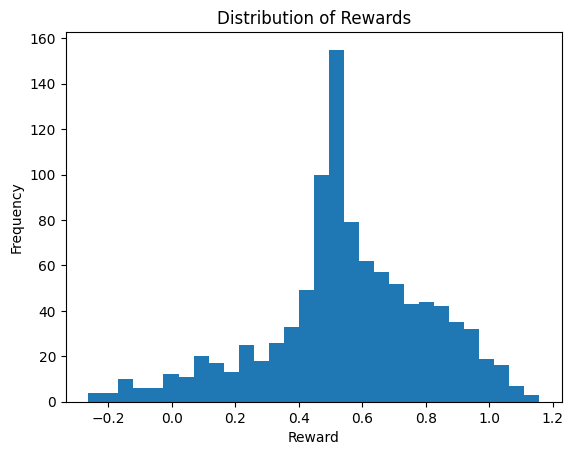

In [54]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(rewards, bins=30)
plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.title("Distribution of Rewards")
plt.show()

In [49]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

def render_state(state):
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    env.reset()

    # manually set state
    env.unwrapped.state = np.array(state)

    frame = env.render()
    env.close()
    return frame

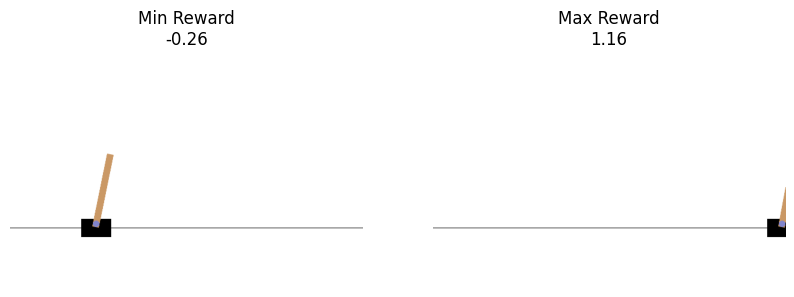

In [50]:
min_img = render_state(min_state)
max_img = render_state(max_state)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(min_img)
plt.title(f"Min Reward\n{rewards[min_idx]:.2f}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(max_img)
plt.title(f"Max Reward\n{rewards[max_idx]:.2f}")
plt.axis("off")

plt.show()

In [53]:
compute_rewards([np.array([0,0,0,0])])

/Users/abhishekmish9909/Documents/repos/RLHF_assignment/utils.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  reward += self.reward_net.forward(torch.tensor(state))


array([0.56946743])

In [63]:
import json

def _collect_epoch_wise_episode_len(file):
    epoch_average_return = {}
    with open(file, "r") as f:
        data = f.readlines()
    for line in data:
        epoch_number = int(line.split("epoch:")[1].split("loss")[0].strip())
        epoch_length = float(line.split("ep_len (gt reward): ")[1].strip())
        epoch_average_return[epoch_number] = epoch_length

    return epoch_average_return

In [64]:
import glob

rlhf_epoch_return_files = glob.glob("log_rlhf_[01234]/log.txt")
rlhf_epoch_average_return_dict = {}
for file in rlhf_epoch_return_files:
    num = int(file.split("log_rlhf_")[1].split("/log")[0].strip())
    rlhf_epoch_average_return_dict[num] = _collect_epoch_wise_episode_len(file)

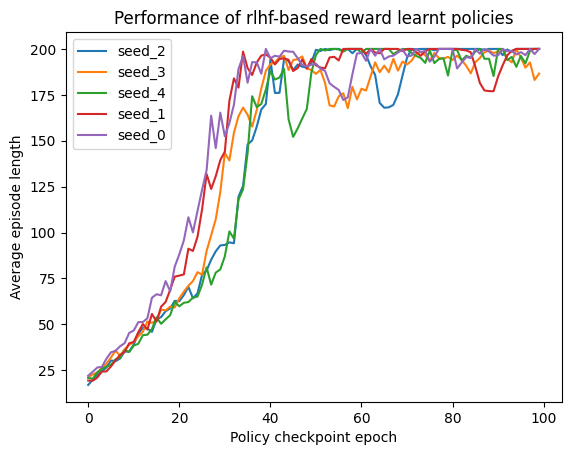

In [65]:
# ----------------------------------------
# Plot 1: original performance plot
# ----------------------------------------
plt.figure()

for run_id, epoch_dict in rlhf_epoch_average_return_dict.items():
    epochs = sorted(epoch_dict.keys())
    values = [epoch_dict[e] for e in epochs]
    plt.plot(epochs, values, label=f"seed_{run_id}")

plt.xlabel("Policy checkpoint epoch")
plt.ylabel("Average episode length")
plt.title("Performance of rlhf-based reward learnt policies")
plt.legend()
plt.show()